# Исследование стратегического поведения в задаче вакцинации



Структура ноутбука:
1. **Этап 2** — модели SIR/V и SVIR для одной изолированной популяции и базовая валидация.
2. **Этап 3** — стратегический выбор вакцинации в одной популяции: равновесие Нэша и социальный оптимум.
3. **Этап 4** — модель двух связанных популяций.
4. **Этапы 5–6** — численные эксперименты по внешнему параметру `y` и вычисление SED.


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from models_2 import (
    SIR_V,
    SIRV,
    herd_immunity_threshold,
    final_size_sir_v,
    infection_probability_unvaccinated,
    simulate_sir_v_ode,
    simulate_svir_ode,
)
from models_2 import SIR_V_CHOICE, TwoCityVaccinationGame

plt.rcParams['figure.figsize'] = (8, 4.8)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.grid'] = True

OUTDIR = Path('diploma_notebook_results')
OUTDIR.mkdir(exist_ok=True)
print(f'Результаты сохранены в: {OUTDIR.resolve()}')


Результаты сохранены в: C:\Users\Oleg\PycharmProjects\diplom_2025\diploma_notebook_results


## Этап 2. SIR/V и SVIR для одной изолированной популяции

Сначала смотрим классическую эпидемическую динамику с предэпидемической вакцинацией (`SIR/V`), затем — модель с вакцинацией в ходе эпидемии (`SVIR`).

Для валидации сравним:
- поведение траекторий при разных уровнях вакцинации;
- финальный размер эпидемии из численного решения и из аналитического final-size relation.


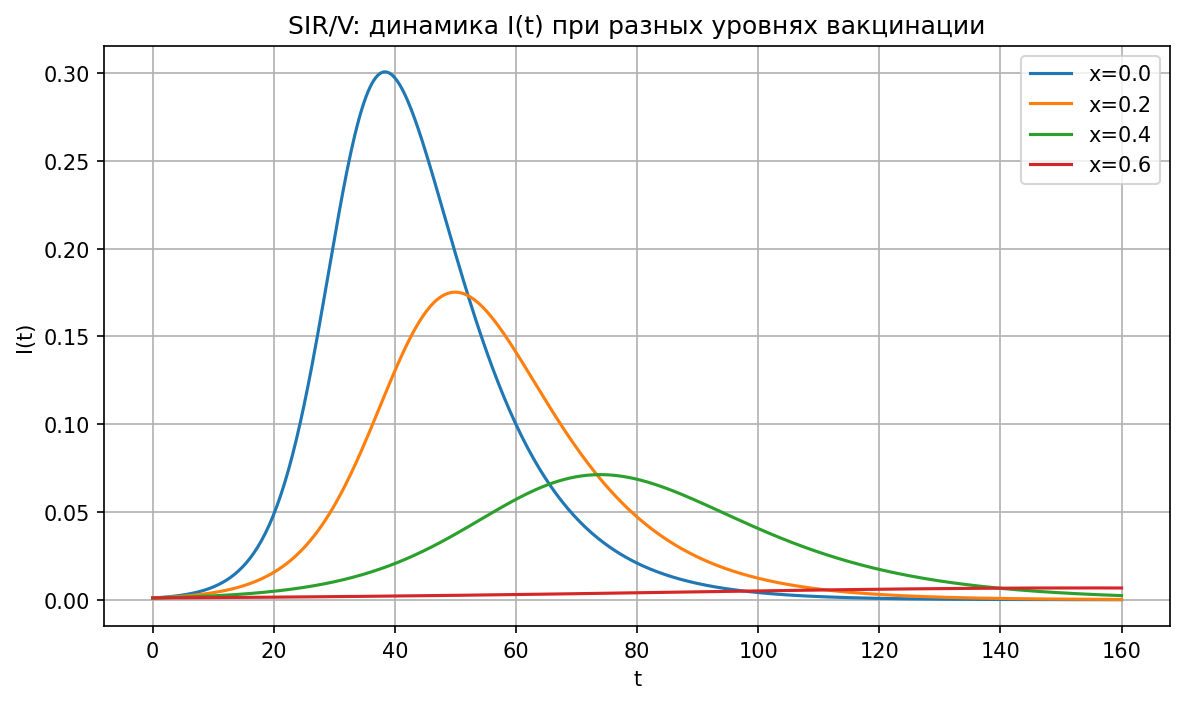

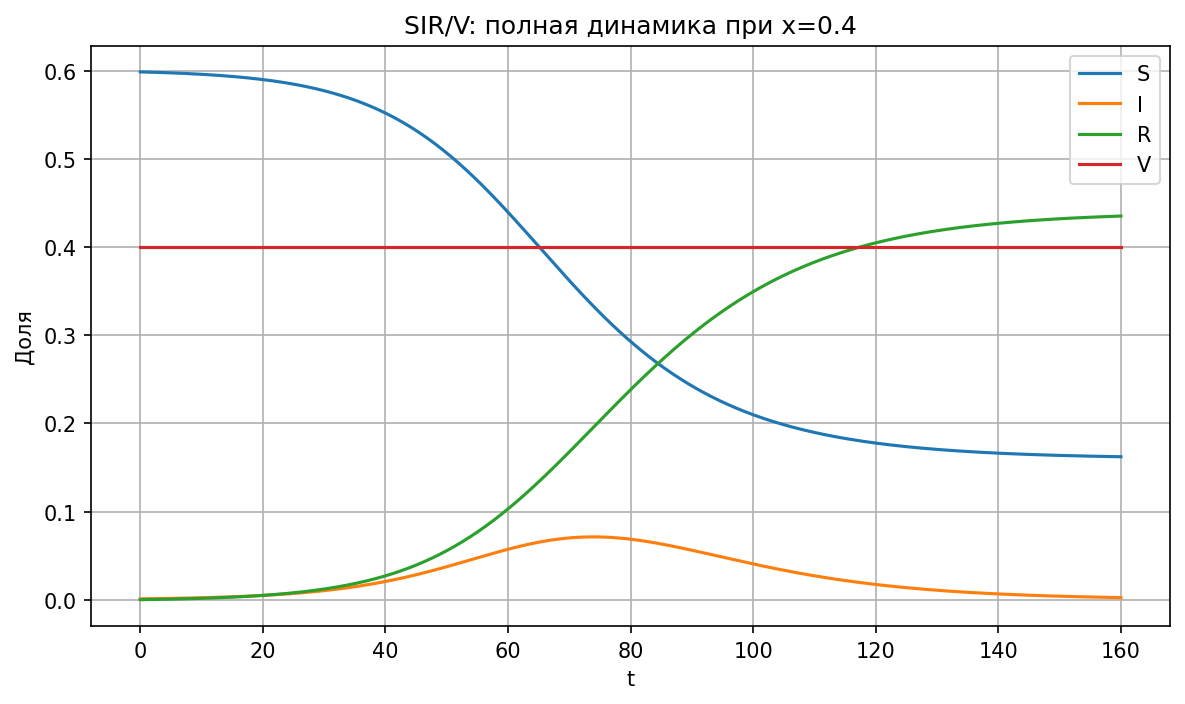

In [2]:
# Базовые параметры для этапа 2
R0 = 3.0
gamma = 0.1
beta = R0 * gamma
x_values = [0.0, 0.2, 0.4, 0.6]
delta = 1e-3

fig, ax = plt.subplots()
for x in x_values:
    df = simulate_sir_v_ode(
        s0=(1 - x) - delta,
        i0=delta,
        r0_init=0.0,
        v=x,
        beta=beta,
        gamma=gamma,
        t_max=160,
        n_eval=500,
    )
    ax.plot(df['timestamp'], df['i'], label=f'x={x:.1f}')
ax.set_title('SIR/V: динамика I(t) при разных уровнях вакцинации')
ax.set_xlabel('t')
ax.set_ylabel('I(t)')
ax.legend()
plt.tight_layout()
plt.savefig(OUTDIR / 'stage2_sirv_infected_curves.png')
plt.show()

# Полная траектория для одного выбранного x
x_rep = 0.4
df_rep = simulate_sir_v_ode(
    s0=(1 - x_rep) - delta,
    i0=delta,
    r0_init=0.0,
    v=x_rep,
    beta=beta,
    gamma=gamma,
    t_max=160,
    n_eval=500,
)
fig, ax = plt.subplots()
for col in ['s', 'i', 'r', 'v']:
    ax.plot(df_rep['timestamp'], df_rep[col], label=col.upper())
ax.set_title('SIR/V: полная динамика при x=0.4')
ax.set_xlabel('t')
ax.set_ylabel('Доля')
ax.legend()
plt.tight_layout()
plt.savefig(OUTDIR / 'stage2_sirv_compartments.png')
plt.show()


,x,final_size_ode,final_size_analytic
0,0.000,0.940552,0.940480
1,0.033,0.902580,0.902497
2,0.066,0.864184,0.864090
3,0.099,0.825327,0.825219
4,0.132,0.785964,0.785840


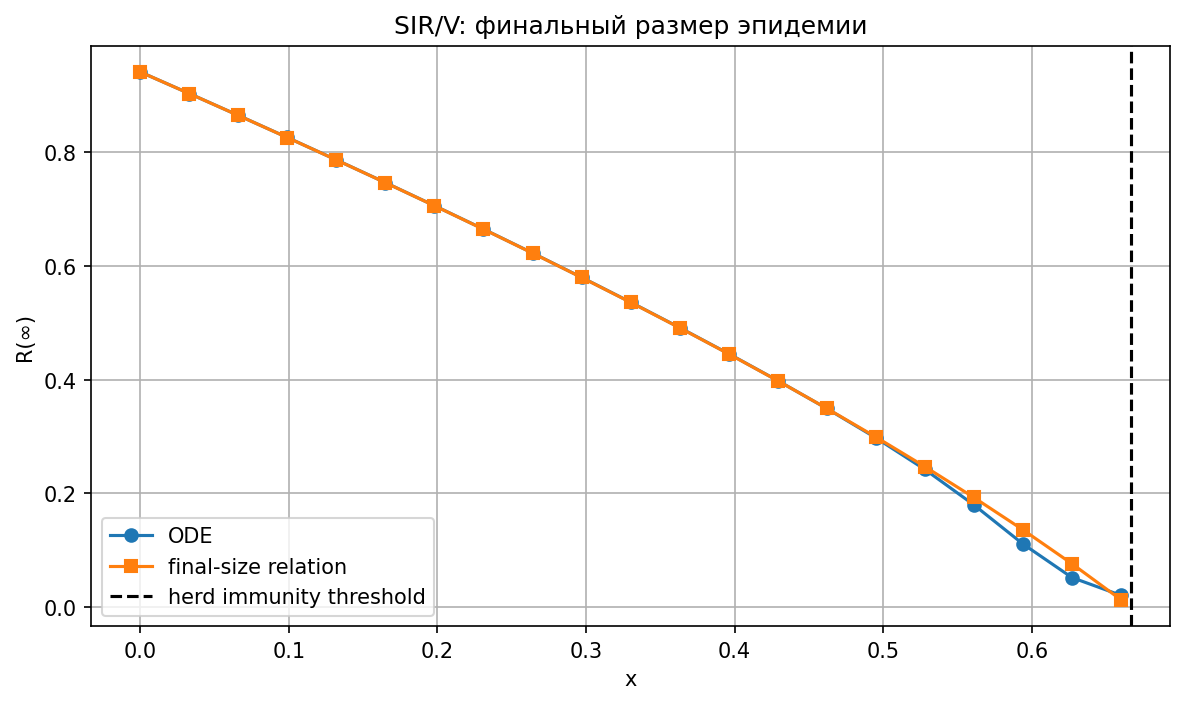

Максимальное абсолютное отклонение ODE от final-size relation: 0.0248


In [3]:
# Валидация SIR/V: сравнение final epidemic size (ODE) и final-size relation
x_grid = np.linspace(0.0, 0.66, 21)
rows = []
for x in x_grid:
    df = simulate_sir_v_ode(
        s0=(1 - x) - delta,
        i0=delta,
        r0_init=0.0,
        v=x,
        beta=beta,
        gamma=gamma,
        t_max=220,
        n_eval=700,
    )
    final_num = float(df['r'].iloc[-1])
    final_analytic = final_size_sir_v(x, r0=R0)
    rows.append({'x': x, 'final_size_ode': final_num, 'final_size_analytic': final_analytic})

sirv_validation = pd.DataFrame(rows)
display(sirv_validation.head())

fig, ax = plt.subplots()
ax.plot(sirv_validation['x'], sirv_validation['final_size_ode'], marker='o', label='ODE')
ax.plot(sirv_validation['x'], sirv_validation['final_size_analytic'], marker='s', label='final-size relation')
ax.axvline(herd_immunity_threshold(R0), linestyle='--', color='black', label='herd immunity threshold')
ax.set_title('SIR/V: финальный размер эпидемии')
ax.set_xlabel('x')
ax.set_ylabel('R(∞)')
ax.legend()
plt.tight_layout()
plt.savefig(OUTDIR / 'stage2_sirv_validation_final_size.png')
plt.show()

max_abs_error = np.max(np.abs(sirv_validation['final_size_ode'] - sirv_validation['final_size_analytic']))
print(f'Максимальное абсолютное отклонение ODE от final-size relation: {max_abs_error:.4f}')


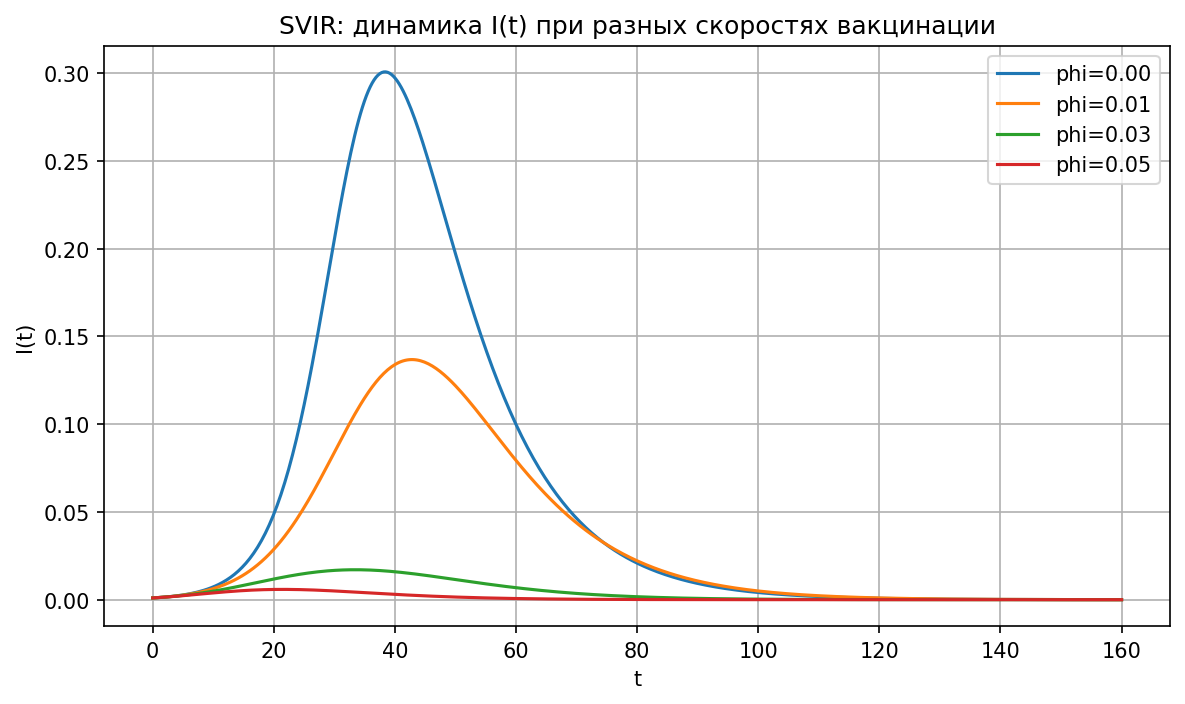

,phi,final_epidemic_size,final_vaccination,peak_infection
0,0.000,0.940552,0.000000,0.300794
1,0.004,0.782001,0.178323,0.228382
2,0.008,0.620551,0.352737,0.164686
3,0.012,0.462544,0.519657,0.112035
4,0.016,0.320807,0.667898,0.072406


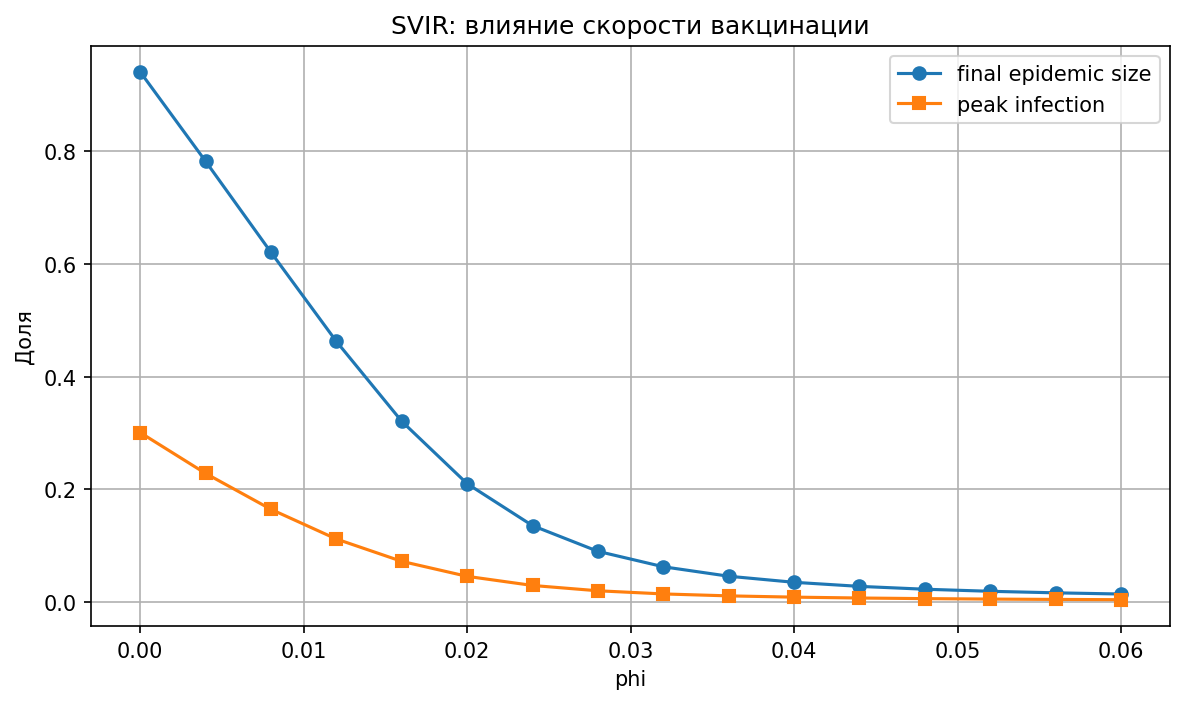

In [4]:
# SVIR: вакцинация во время эпидемии
phi_values = [0.0, 0.01, 0.03, 0.05]
fig, ax = plt.subplots()
for phi in phi_values:
    df = simulate_svir_ode(
        s0=1.0 - delta,
        i0=delta,
        r0_init=0.0,
        v0=0.0,
        phi=phi,
        beta=beta,
        gamma=gamma,
        t_max=160,
        n_eval=500,
    )
    ax.plot(df['timestamp'], df['i'], label=f'phi={phi:.2f}')
ax.set_title('SVIR: динамика I(t) при разных скоростях вакцинации')
ax.set_xlabel('t')
ax.set_ylabel('I(t)')
ax.legend()
plt.tight_layout()
plt.savefig(OUTDIR / 'stage2_svir_infected_curves.png')
plt.show()

phi_grid = np.linspace(0.0, 0.06, 16)
rows = []
for phi in phi_grid:
    df = simulate_svir_ode(
        s0=1.0 - delta,
        i0=delta,
        r0_init=0.0,
        v0=0.0,
        phi=phi,
        beta=beta,
        gamma=gamma,
        t_max=220,
        n_eval=700,
    )
    rows.append({
        'phi': phi,
        'final_epidemic_size': float(df['r'].iloc[-1]),
        'final_vaccination': float(df['v'].iloc[-1]),
        'peak_infection': float(df['i'].max()),
    })

svir_scan = pd.DataFrame(rows)
display(svir_scan.head())

fig, ax = plt.subplots()
ax.plot(svir_scan['phi'], svir_scan['final_epidemic_size'], marker='o', label='final epidemic size')
ax.plot(svir_scan['phi'], svir_scan['peak_infection'], marker='s', label='peak infection')
ax.set_title('SVIR: влияние скорости вакцинации')
ax.set_xlabel('phi')
ax.set_ylabel('Доля')
ax.legend()
plt.tight_layout()
plt.savefig(OUTDIR / 'stage2_svir_scan.png')
plt.show()


### Краткий вывод по этапу 2

- При увеличении доли предварительно вакцинированных `x` пик инфекции падает, а финальный размер эпидемии уменьшается.
- Численное решение `SIR/V` хорошо согласуется с аналитическим final-size relation.
- В `SVIR` рост скорости вакцинации `phi` уменьшает пик инфекции и итоговый размер вспышки.


## Этап 3. Стратегический выбор вакцинации в одной популяции

Теперь добавляем индивидуальные и социальные издержки:
- стоимость вакцинации `c_v`;
- ущерб от инфекции `c_i`.

Для однопопуляционной модели считаем:
- `x*` — равновесие Нэша из условия безразличия между вакцинацией и отказом;
- `x_opt` — социальный оптимум, минимизирующий средние издержки.


In [5]:
# Базовый сценарий для этапа 3
choice_model = SIR_V_CHOICE(
    s=0.999,
    i=0.001,
    r=0.0,
    r_coef=3.0,
    c_i=10.0,
    c_v=4.0,
    treshhold=0.0005,
    smoothness=0.1,
    max_iter=5000,
)

summary = choice_model.analyze_equilibria()
display(pd.DataFrame(summary).T)


АНАЛИЗ РАВНОВЕСИЙ МОДЕЛИ ВАКЦИНАЦИИ

ПАРАМЕТРЫ МОДЕЛИ:
R0: 3.000
gamma: 0.100
beta: 0.300
c_v: 4.000
c_i: 10.000
Порог коллективного иммунитета: 0.6667

РАВНОВЕСИЕ НЭША:
v*: 0.5743
P_infect(v*): 0.4000
Социальные издержки при v*: 4.0000
Тип: mixed equilibrium
Проверка условия c_i * P_infect = c_v: 4.0000 vs 4.0000

СОЦИАЛЬНЫЙ ОПТИМУМ:
v_opt: 0.6667
P_infect(v_opt): 0.0000
Социальные издержки при v_opt: 2.6667

СРАВНЕНИЕ:
Разница издержек: 1.3333
Разрыв по вакцинации: 0.0924
Эффективность: неэффективно


,R0,beta,gamma,c_v,c_i,herd_threshold,vaccination_rate,infection_prob,social_cost,equilibrium_type,condition_check,cost_difference,is_efficient,vaccination_gap
parameters,3.0,0.3,0.1,4.0,10.0,0.666667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nash_equilibrium,NaN,NaN,NaN,NaN,NaN,NaN,0.574312,0.4,4.0,mixed equilibrium,4.0,NaN,NaN,NaN
pareto_optimum,NaN,NaN,NaN,NaN,NaN,NaN,0.666669,0.0,2.666675,NaN,NaN,NaN,NaN,NaN
efficiency_analysis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.333325,False,0.092357


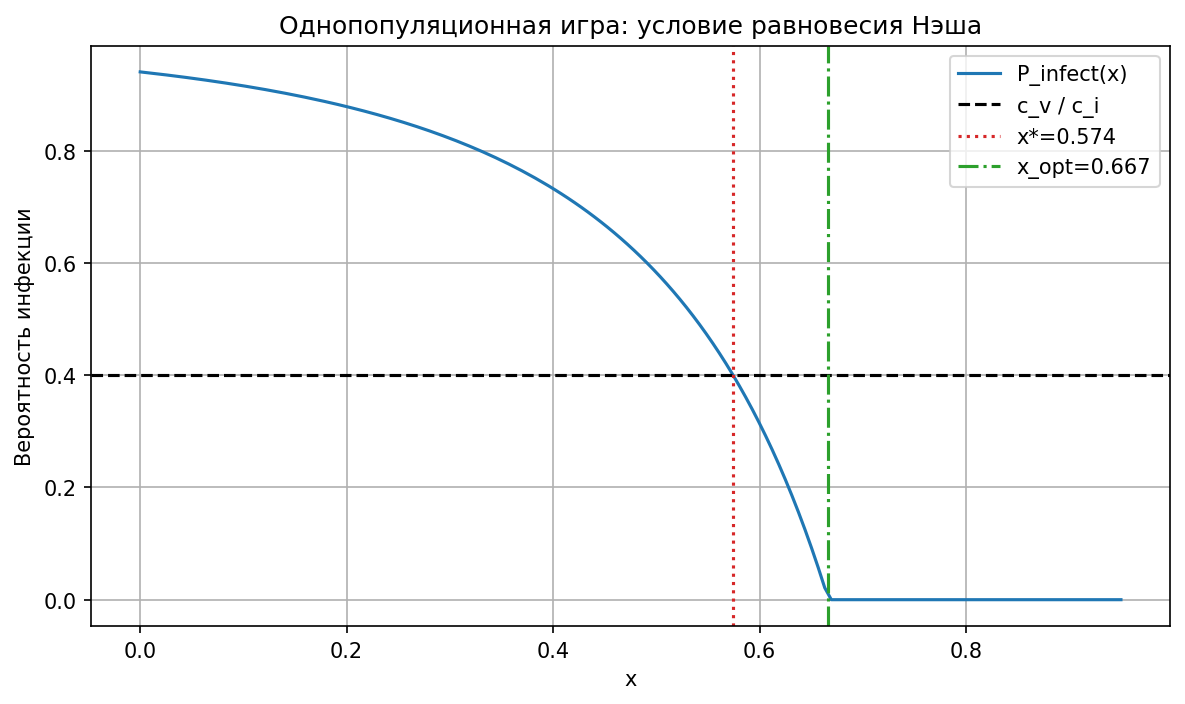

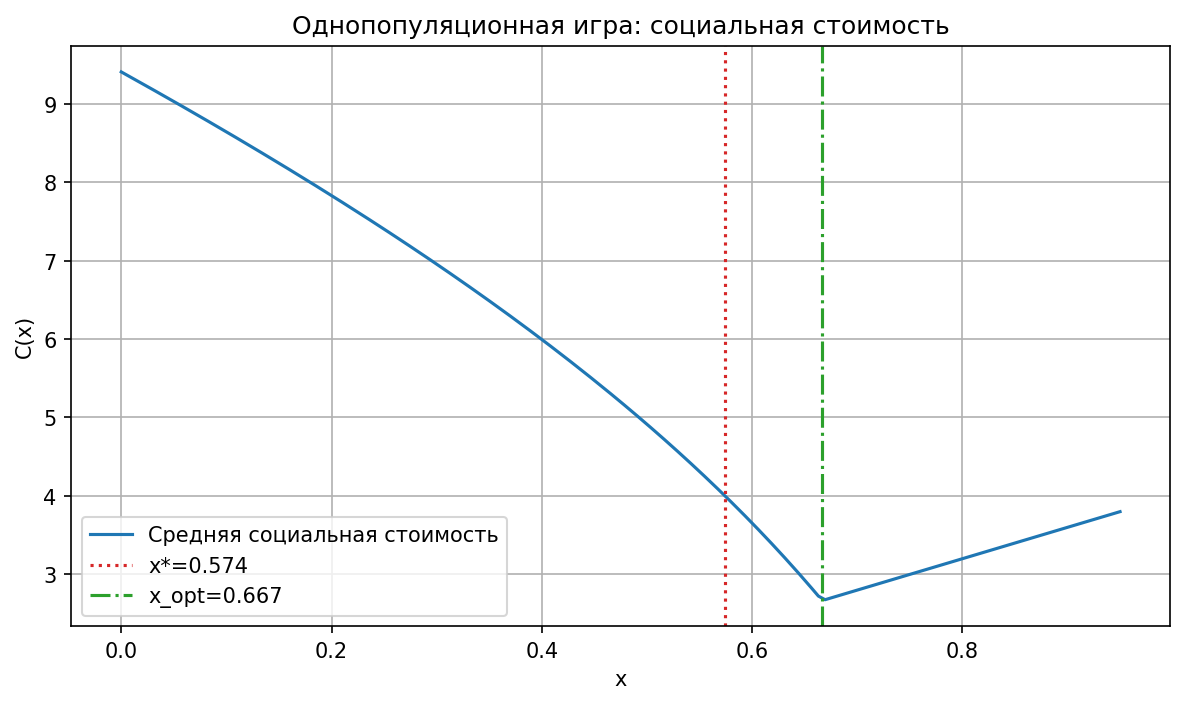

In [6]:
# P_infect(x), социальная стоимость и отметки x* / x_opt
x_grid = np.linspace(0.0, 0.95, 150)
p_grid = np.array([choice_model.get_infection_prob(x) for x in x_grid])
cost_grid = np.array([choice_model.get_social_score(x, choice_model.get_infection_prob(x)) for x in x_grid])

x_nash, p_nash, cost_nash, _, _ = choice_model.get_nash_equilibrium()
x_opt, p_opt, cost_opt = choice_model.get_pareto_equilibrium()

fig, ax = plt.subplots()
ax.plot(x_grid, p_grid, label='P_infect(x)')
ax.axhline(choice_model.c_v / choice_model.c_i, linestyle='--', color='black', label='c_v / c_i')
ax.axvline(x_nash, linestyle=':', color='tab:red', label=f'x*={x_nash:.3f}')
ax.axvline(x_opt, linestyle='-.', color='tab:green', label=f'x_opt={x_opt:.3f}')
ax.set_title('Однопопуляционная игра: условие равновесия Нэша')
ax.set_xlabel('x')
ax.set_ylabel('Вероятность инфекции')
ax.legend()
plt.tight_layout()
plt.savefig(OUTDIR / 'stage3_one_city_equilibrium.png')
plt.show()

fig, ax = plt.subplots()
ax.plot(x_grid, cost_grid, label='Средняя социальная стоимость')
ax.axvline(x_nash, linestyle=':', color='tab:red', label=f'x*={x_nash:.3f}')
ax.axvline(x_opt, linestyle='-.', color='tab:green', label=f'x_opt={x_opt:.3f}')
ax.set_title('Однопопуляционная игра: социальная стоимость')
ax.set_xlabel('x')
ax.set_ylabel('C(x)')
ax.legend()
plt.tight_layout()
plt.savefig(OUTDIR / 'stage3_one_city_social_cost.png')
plt.show()


,c_v,x_nash,x_opt,p_nash,p_opt,cost_nash,cost_opt,sed
0,0.500000,0.658045,0.666669,0.050000,0.000000,0.500000,0.333335,0.333331
1,0.894737,0.650801,0.666669,0.089474,0.000000,0.894737,0.596494,0.333331
2,1.289474,0.643129,0.666671,0.128947,0.000000,1.289474,0.859655,0.333329
3,1.684211,0.634984,0.666666,0.168421,0.000001,1.684211,1.122811,0.333331
4,2.078947,0.626316,0.666671,0.207895,0.000000,2.078947,1.385974,0.333329


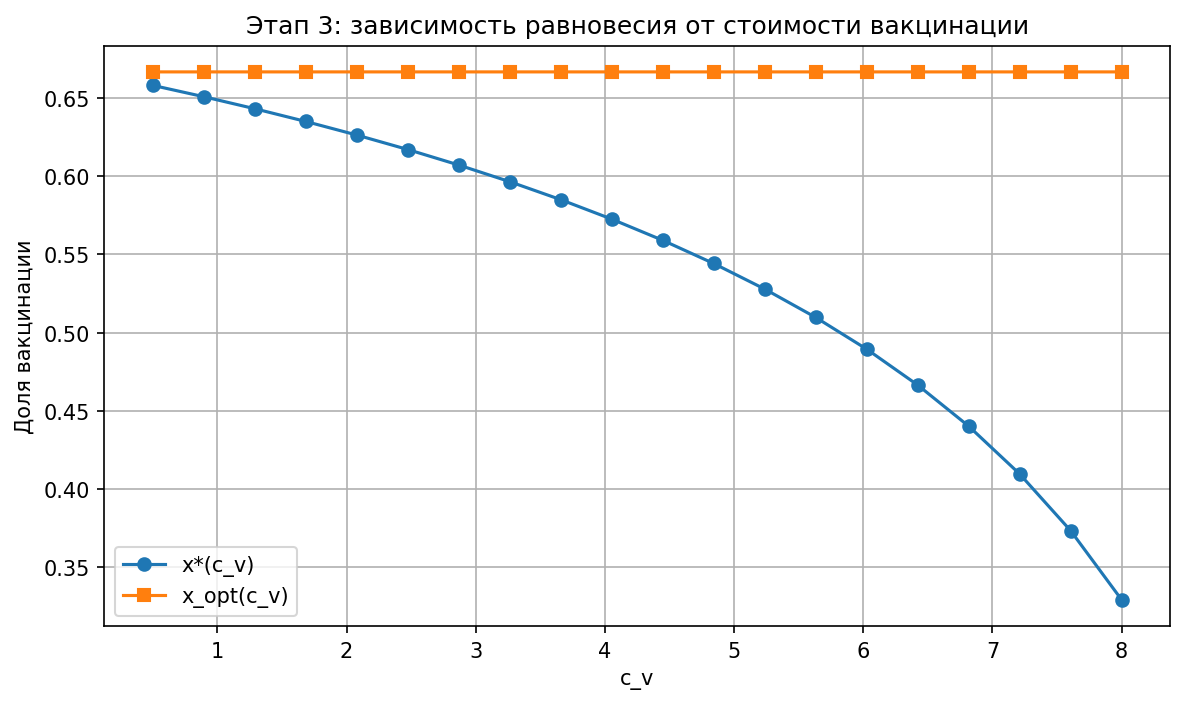

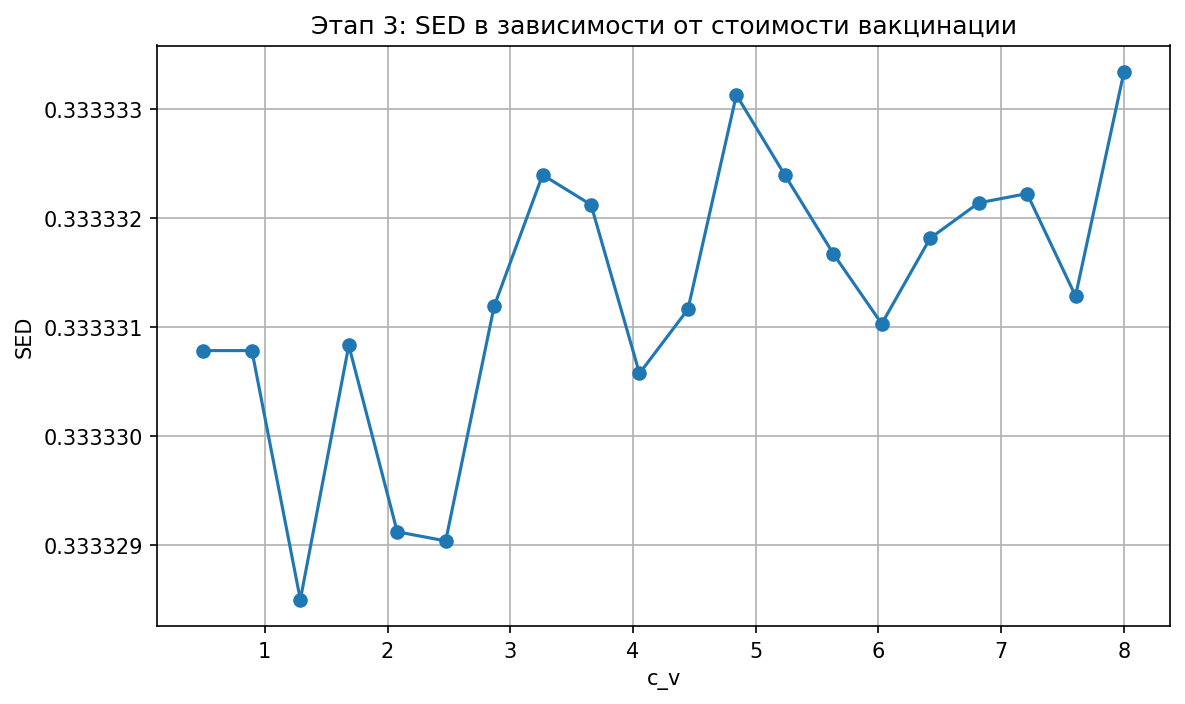

In [13]:
# Как меняются x* и x_opt при изменении стоимости вакцинации
c_v_grid = np.linspace(0.5, 8.0, 20)
rows = []
for c_v in c_v_grid:
    model = SIR_V_CHOICE(
        s=0.999,
        i=0.001,
        r=0.0,
        r_coef=3.0,
        c_i=10.0,
        c_v=float(c_v),
        treshhold=0.0005,
        smoothness=0.1,
        max_iter=5000,
    )
    x_nash, p_nash, cost_nash, _, _ = model.get_nash_equilibrium()
    x_opt, p_opt, cost_opt = model.get_pareto_equilibrium()
    sed = (cost_nash - cost_opt) / cost_nash if cost_nash > 1e-12 else 0.0
    rows.append({
        'c_v': c_v,
        'x_nash': x_nash,
        'x_opt': x_opt,
        'p_nash': p_nash,
        'p_opt': p_opt,
        'cost_nash': cost_nash,
        'cost_opt': cost_opt,
        'sed': sed,
    })

cost_scan = pd.DataFrame(rows)
display(cost_scan.head())

fig, ax = plt.subplots()
ax.plot(cost_scan['c_v'], cost_scan['x_nash'], marker='o', label='x*(c_v)')
ax.plot(cost_scan['c_v'], cost_scan['x_opt'], marker='s', label='x_opt(c_v)')
ax.set_title('Этап 3: зависимость равновесия от стоимости вакцинации')
ax.set_xlabel('c_v')
ax.set_ylabel('Доля вакцинации')
ax.legend()
plt.tight_layout()
plt.savefig(OUTDIR / 'stage3_scan_by_cv.png')
plt.show()

fig, ax = plt.subplots()
ax.plot(cost_scan['c_v'], cost_scan['sed'], marker='o')
ax.ticklabel_format(axis='y', style='plain', useOffset=False)
ax.set_title('Этап 3: SED в зависимости от стоимости вакцинации')
ax.set_xlabel('c_v')
ax.set_ylabel('SED')
plt.tight_layout()
plt.savefig(OUTDIR / 'stage3_sed_by_cv.png')
plt.show()


,R0,x_nash,x_opt,sed
0,1.200000,0.000000,0.166669,0.787479
1,1.394118,0.083962,0.282700,0.717298
2,1.588235,0.195923,0.370372,0.629628
3,1.782353,0.283495,0.438947,0.561053
4,1.976471,0.353866,0.494048,0.505952


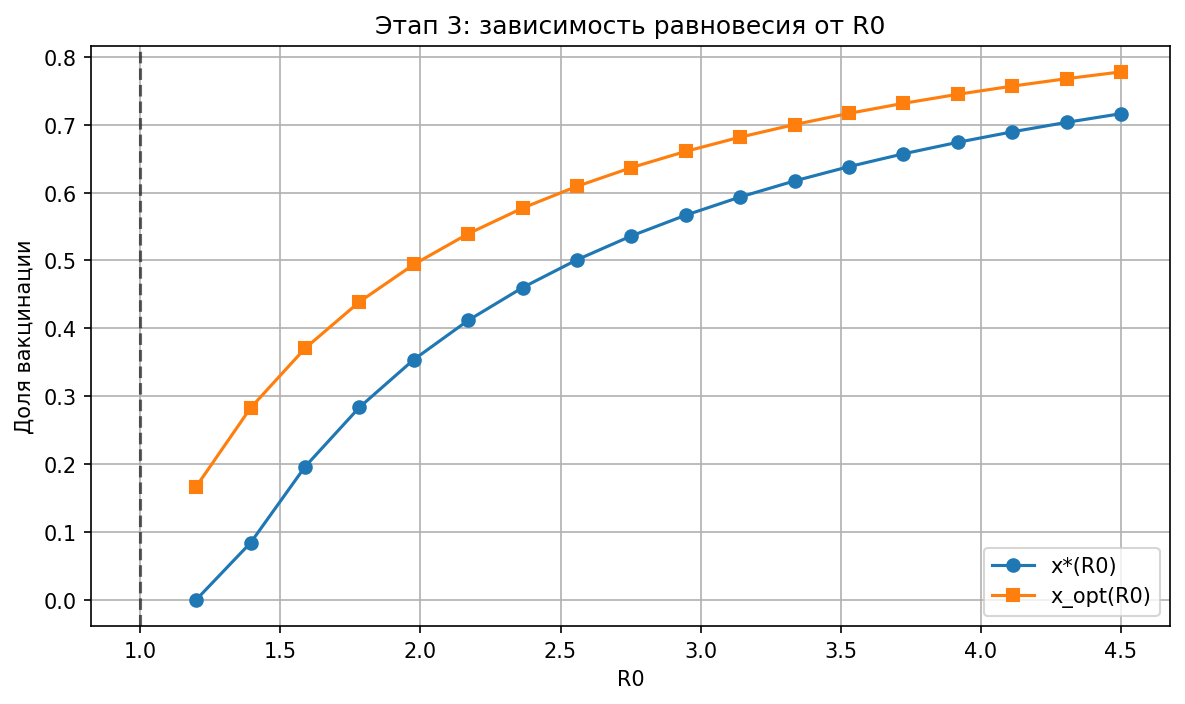

In [8]:
# Как меняются x* и x_opt при изменении R0
r0_grid = np.linspace(1.2, 4.5, 18)
rows = []
for r0 in r0_grid:
    model = SIR_V_CHOICE(
        s=0.999,
        i=0.001,
        r=0.0,
        r_coef=float(r0),
        c_i=10.0,
        c_v=4.0,
        treshhold=0.0005,
        smoothness=0.1,
        max_iter=5000,
    )
    x_nash, p_nash, cost_nash, _, _ = model.get_nash_equilibrium()
    x_opt, p_opt, cost_opt = model.get_pareto_equilibrium()
    sed = (cost_nash - cost_opt) / cost_nash if cost_nash > 1e-12 else 0.0
    rows.append({
        'R0': r0,
        'x_nash': x_nash,
        'x_opt': x_opt,
        'sed': sed,
    })

r0_scan = pd.DataFrame(rows)
display(r0_scan.head())

fig, ax = plt.subplots()
ax.plot(r0_scan['R0'], r0_scan['x_nash'], marker='o', label='x*(R0)')
ax.plot(r0_scan['R0'], r0_scan['x_opt'], marker='s', label='x_opt(R0)')
ax.axvline(1.0, linestyle='--', color='black', alpha=0.6)
ax.set_title('Этап 3: зависимость равновесия от R0')
ax.set_xlabel('R0')
ax.set_ylabel('Доля вакцинации')
ax.legend()
plt.tight_layout()
plt.savefig(OUTDIR / 'stage3_scan_by_r0.png')
plt.show()


### Краткий вывод по этапу 3

- Индивидуальное равновесие `x*` обычно меньше социального оптимума `x_opt`.
- При росте стоимости вакцинации оба уровня вакцинации падают.
- При росте `R0` рациональная и социально оптимальная вакцинация возрастают.
- Положительный `SED` указывает на существование социальной дилеммы.


## Этап 4. Две связанные популяции

Теперь переходим к модели двух городов. В городе `A` ищем стратегическое поведение, а в городе `B` считаем долю вакцинации `y` внешним параметром.


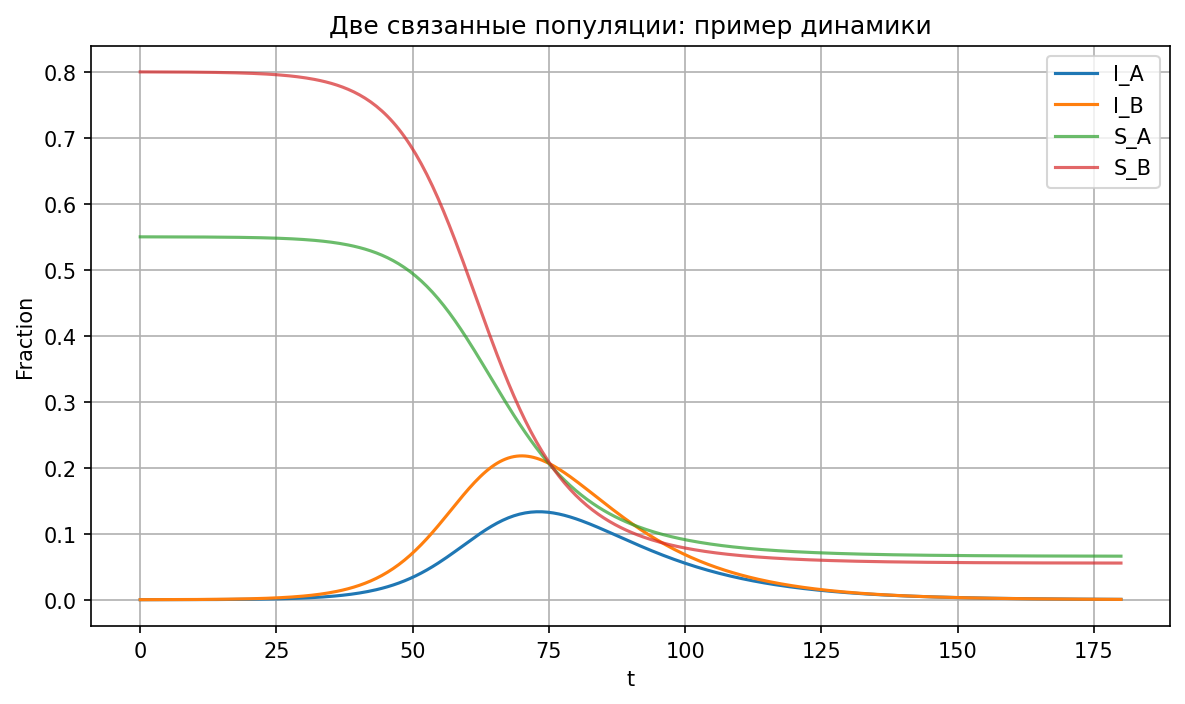

In [9]:
two_city = TwoCityVaccinationGame(
    r_coef=3.0,
    smoothness=0.08,
    epsilon=0.3,
    c_i=1.0,
    c_v=0.4,
    delta=1e-4,
    max_time=180,
    n_eval=350,
)

two_city.plot_example_dynamics(x=0.45, y=0.20, title='Две связанные популяции: пример динамики')


## Этапы 5–6. Численные эксперименты по параметру `y` и показатель SED

На этом этапе строим зависимости:
- `x*(y)` — равновесная вакцинация в городе A;
- `x_opt(y)` — общественно оптимальная вакцинация в городе A;
- `SED(y)` — нормированный дефицит социальной эффективности.


,y,x_nash,x_opt,p_nash,p_opt,cost_nash,cost_opt,sed_raw,sed_norm,nash_type
0,0.00,0.999999,0.999993,0.570927,0.570931,0.4,0.400001,-1.018901e-06,0.0,boundary_1
1,0.06,0.999999,0.999993,0.543182,0.543186,0.4,0.400001,-8.535179e-07,0.0,boundary_1
2,0.12,0.999999,0.999993,0.512869,0.512874,0.4,0.400001,-6.728303e-07,0.0,boundary_1
3,0.18,0.999999,0.999993,0.479433,0.479437,0.4,0.400001,-4.735189e-07,0.0,boundary_1
4,0.24,0.999999,0.999993,0.441879,0.441884,0.4,0.400000,-2.496681e-07,0.0,boundary_1


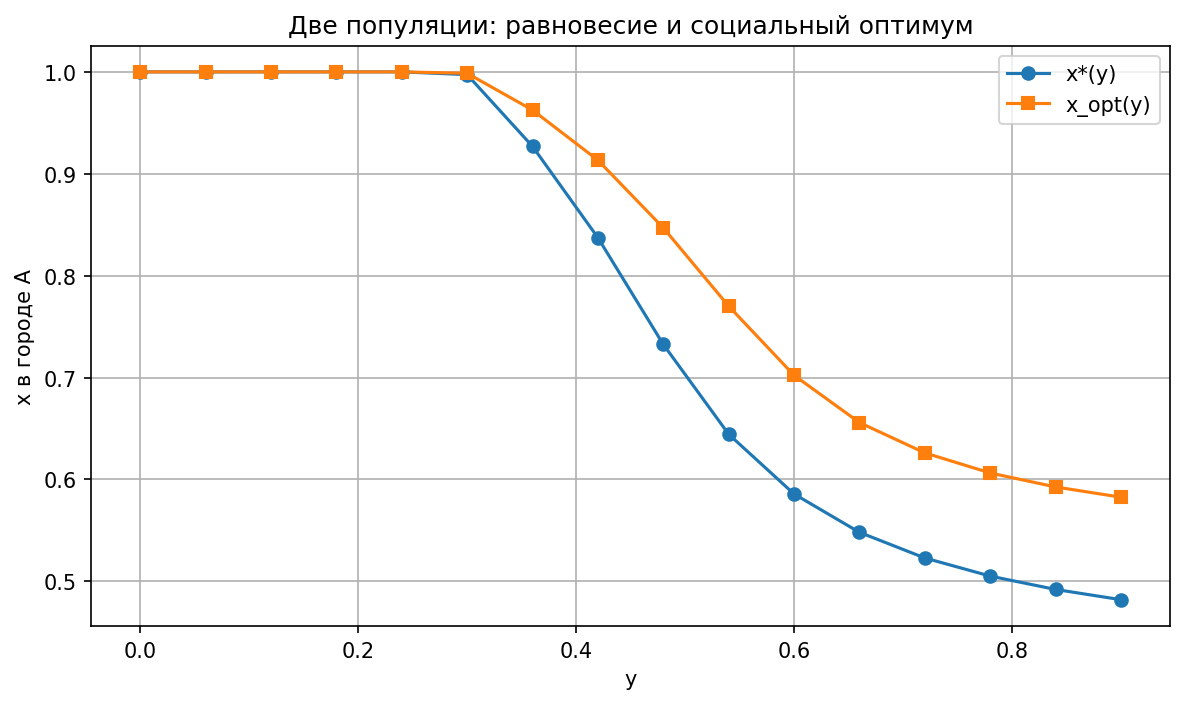

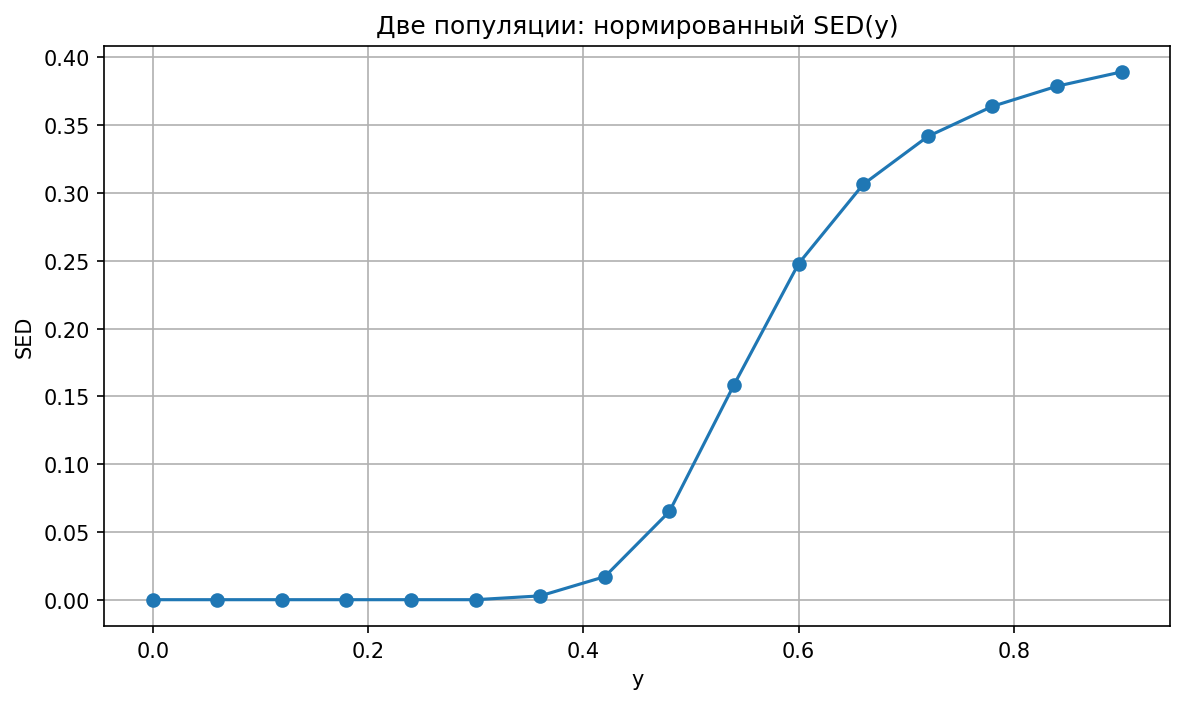

In [10]:
y_grid = np.linspace(0.0, 0.9, 16)
res = two_city.run_grid(y_grid)
display(res.head())
res.to_csv(OUTDIR / 'two_city_scan.csv', index=False)

fig, ax = plt.subplots()
ax.plot(res['y'], res['x_nash'], marker='o', label='x*(y)')
ax.plot(res['y'], res['x_opt'], marker='s', label='x_opt(y)')
ax.set_title('Две популяции: равновесие и социальный оптимум')
ax.set_xlabel('y')
ax.set_ylabel('x в городе A')
ax.legend()
plt.tight_layout()
plt.savefig(OUTDIR / 'stage5_xcurves.png')
plt.show()

fig, ax = plt.subplots()
ax.plot(res['y'], res['sed_norm'], marker='o')
ax.set_title('Две популяции: нормированный SED(y)')
ax.set_xlabel('y')
ax.set_ylabel('SED')
plt.tight_layout()
plt.savefig(OUTDIR / 'stage6_sed.png')
plt.show()


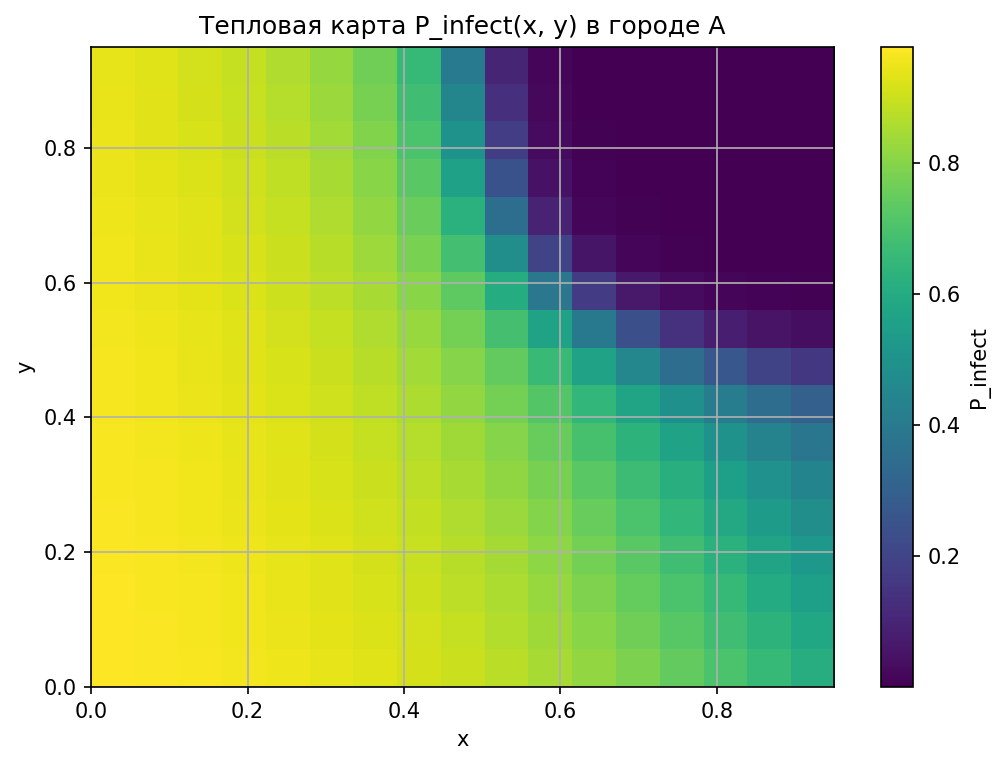

In [11]:
# Тепловая карта P_infect(x, y) для города A
x_grid = np.linspace(0.0, 0.95, 17)
y_grid = np.linspace(0.0, 0.95, 17)
P = np.zeros((len(y_grid), len(x_grid)))
for iy, y in enumerate(y_grid):
    for ix, x in enumerate(x_grid):
        P[iy, ix] = two_city.infection_probability_A(float(x), float(y))

fig, ax = plt.subplots(figsize=(7, 5.2))
im = ax.imshow(P, origin='lower', aspect='auto', extent=[x_grid.min(), x_grid.max(), y_grid.min(), y_grid.max()])
ax.set_title('Тепловая карта P_infect(x, y) в городе A')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.colorbar(im, ax=ax, label='P_infect')
plt.tight_layout()
plt.savefig(OUTDIR / 'stage6_heatmap_pinfect.png')
plt.show()


In [12]:
print('Ключевые наблюдения:')
print('- При росте y равновесная вакцинация в городе A обычно снижается: часть защиты обеспечивается второй популяцией.')
print('- x_opt(y) остаётся выше x*(y), если сохраняется социальная дилемма.')
print('- Ненулевой SED(y) показывает потери от расхождения между индивидуально рациональным и социально оптимальным поведением.')
print() 
print('Файлы с рисунками и таблицами сохранены в каталоге:', OUTDIR)


Ключевые наблюдения:
- При росте y равновесная вакцинация в городе A обычно снижается: часть защиты обеспечивается второй популяцией.
- x_opt(y) остаётся выше x*(y), если сохраняется социальная дилемма.
- Ненулевой SED(y) показывает потери от расхождения между индивидуально рациональным и социально оптимальным поведением.

Файлы с рисунками и таблицами сохранены в каталоге: diploma_notebook_results
